In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import shutil
import os

from gtf import constants
from gtf import initial_conditions
from gtf import state
from gtf import time_evolution

In [2]:
#first non-zero radius at t=0
r_first = constants.FLOATDTYPE(0.001)

#outermost radius (innermost is set to zer)
constants.R_OUTER = constants.FLOATDTYPE(200.0)

#number of shells
constants.N_SHELL = 200

#SIDM cross section
constants.SIGMA_OVER_M = constants.FLOATDTYPE(0.3)

#LMFP conductivity constant
constants.BETA = constants.FLOATDTYPE(0.8)

#transition parameter
constants.ALPHA = constants.FLOATDTYPE(1.0)

#convergence of Newton iterations
constants.F_TOL = constants.FLOATDTYPE(1.0e-10)

#stagnated but acceptable
constants.F_ACCEPT = constants.FLOATDTYPE(1.0e-8)

#determines stagnation
constants.X_TOL = constants.FLOATDTYPE(1.0e-10)

#maximum allowed iterations
constants.ITER_MAX = 50

#timestep controller
constants.DT_TOL = constants.FLOATDTYPE(0.01)

#total time limiter
constants.RHO_STOP = constants.FLOATDTYPE(1.0e8)

#output directory
out_direc = ("data/nfw_beta_%.2f_alpha_%.2f_rfirst_%.4f_router_%.1f_Nshell_%d_timesteptol_%.4f/" 
             %(constants.BETA, constants.ALPHA, r_first, constants.R_OUTER, constants.N_SHELL, constants.DT_TOL))

if os.path.exists(out_direc):
    shutil.rmtree(out_direc)

os.makedirs(out_direc)

constants.OUT_DIREC = out_direc

#controls output frequency 
constants.OUTPUT_FACTOR = 1.02

In [3]:
#set up NFW halo at t=0
ln_r_edge, u = initial_conditions.set_up_initial_conditions(r_first)

In [4]:
#create initial state of the system with all relevant state variables
state_init = state.state_from_unknowns(ln_r_edge, u)

In [5]:
#evolve the halo until central density is greater than constants.RHO_STOP

start_time = time.perf_counter()

time_evolution.evolve(state_init)

end_time = time.perf_counter()

execution_time = end_time - start_time

Newton iteration 1 
 max(F) =  0.0060295691525870665 
 max(dx) =  0.07446807045005051 
 alpha =  1.0
Newton iteration 2 
 max(F) =  1.154343967735283e-05 
 max(dx) =  0.002352489258006984 
 alpha =  1.0
Newton iteration 3 
 max(F) =  4.996658642397733e-11 
 max(dx) =  8.102320149261439e-06 
 alpha =  1.0
Newton iterations have converged in  3 iterations.
reject: dt = 0.001 eps = 0.07700447120818148 new dt = 0.00011687633015060272
Newton iteration 1 
 max(F) =  0.00015422009095852895 
 max(dx) =  0.0079660728246944 
 alpha =  1.0
Newton iteration 2 
 max(F) =  3.086143035568867e-09 
 max(dx) =  3.2730472605087335e-05 
 alpha =  1.0
Newton iteration 3 
 max(F) =  3.329836406607001e-13 
 max(dx) =  1.4713591464122051e-09 
 alpha =  1.0
Newton iterations have converged in  3 iterations.
accept: t= 0.00011687633015060272 dt = 0.00011687633015060272 eps = 0.007978218234546922 new dt = 0.00013184484811415545 rho_0= 1966.904577118283
Newton iteration 1 
 max(F) =  0.00011347762155897168 
 max(

In [6]:
execution_time

143.23629949998576

In [7]:
data=np.loadtxt(constants.OUT_DIREC+'stats.txt')

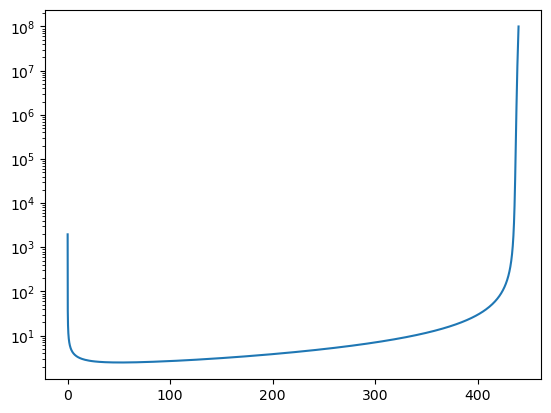

In [13]:
fig,ax=plt.subplots()
ax.plot(data[:,0],data[:,5])
ax.set_yscale('log')